In [92]:
import pandas as pd
from sklearn.datasets import load_breast_cancer


df = load_breast_cancer(as_frame=True).frame

### Data Loading

This cell loads the Breast Cancer dataset from `sklearn.datasets` into a pandas DataFrame. The `as_frame=True` argument ensures that the data is loaded as a DataFrame, making it easier to work with.

In [ ]:
print(df.head().to_string())

### Initial Data Inspection

This cell displays the first 5 rows of the DataFrame using `df.head().to_string()` to get an initial overview of the data, including feature names and some sample values.

In [ ]:
df.info()

### Data Information

This cell uses `df.info()` to print a concise summary of the DataFrame. This includes the data types of each column, the number of non-null values, and memory usage. This helps in identifying missing values and confirming data types.

In [ ]:
df.dtypes

### Check Data Types

This cell explicitly checks and displays the data types of all columns in the DataFrame using `df.dtypes`. This is crucial for verifying that numerical features are correctly interpreted as such.

In [ ]:
df.isnull().sum()

### Check for Missing Values

This cell calculates the sum of null values for each column using `df.isnull().sum()`. This helps identify if any features have missing data that would require imputation or removal.

In [97]:
df.duplicated().sum()

np.int64(0)

### Check for Duplicate Rows

This cell checks for duplicate rows in the DataFrame using `df.duplicated().sum()`. Identifying and handling duplicate entries is an important step in data cleaning.

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

## Data Cleaning and Preprocessing

1. **Missing Values Check**

   * Function: `df.isnull().sum()`
   * Result: The dataset contains **no missing (null) values**, so no imputation was required.

2. **Duplicate Records Check**

   * Function: `df.duplicated().sum()`
   * Result: **No duplicate rows** were found in the dataset.

3. **Data Type Validation**

   * Function: `df.info()`
   * Result: All 30 feature columns are stored as **float64**, while the target column is **int64**. No incorrect data types were detected.

4. **Invalid/String Values Check**

   * Function: `df.info()`
   * Result: The dataset contains **no string or object-type columns**. All input features are numeric and suitable for machine learning models.

5. **Feature Scaling**

   * Function: `StandardScaler()`
   * Result: The feature values have different numerical ranges (e.g., *area* features are much larger than *smoothness* features). Therefore, **StandardScaler** was applied to standardize the features before training distance- and gradient-based classification models
    
   Note: this function will be applied below in the pipeleline.


In [99]:
from sklearn.model_selection import train_test_split

X = df.drop('target',axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

### Data Splitting

This cell splits the dataset into features (`X`) and the target variable (`y`). It then uses `train_test_split` to divide the data into training and testing sets, with 70% for training and 30% for testing. `random_state` ensures reproducibility.

In [100]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

### Model Pipeline Definition

This cell defines a machine learning pipeline using `sklearn.pipeline.Pipeline`. The pipeline consists of two steps:
1. **StandardScaler**: Standardizes features by removing the mean and scaling to unit variance.
2. **LogisticRegression**: A logistic regression model for classification.

In [101]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs", "liblinear","sag", "saga"],
    "model__class_weight": [None, "balanced"]
}

### Hyperparameter Grid Definition

This cell defines the `param_grid` for `GridSearchCV`. It specifies a range of hyperparameters for the `LogisticRegression` model to be tuned:
- `C`: Inverse of regularization strength.
- `solver`: Algorithm to use in the optimization problem.
- `class_weight`: Weights associated with classes.

In [102]:
grid = GridSearchCV(

    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,

)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__solver': ['lbfgs', 'liblinear', 'sag',
                                           'saga']},
             scoring='accuracy')

### Hyperparameter Tuning with GridSearchCV

This cell initializes `GridSearchCV` with the defined pipeline and parameter grid. It performs a 5-fold cross-validation (`cv=5`) to find the best combination of hyperparameters that maximize 'accuracy'. The `n_jobs=-1` parameter uses all available processors for faster computation. Finally, it fits the grid search to the training data.

In [103]:
print(grid.best_params_)
print(grid.best_score_)

{'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'liblinear'}
0.977373417721519


### Display Best Parameters and Score

After `GridSearchCV` completes, this cell prints the best hyperparameters found by the grid search (`grid.best_params_`) and the corresponding best cross-validation score (`grid.best_score_`), which indicates the highest accuracy achieved.

In [104]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

### Model Prediction

This cell retrieves the `best_estimator_` (the model with the optimal hyperparameters) from the `GridSearchCV` object. It then uses this best model to make predictions on the unseen test data (`X_test`), storing the results in `y_pred`.

In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.9941520467836257
Precision: 0.9908256880733946
Recall   : 1.0
F1 Score : 0.9953917050691244


### Model Evaluation


Accuracy

Definition: Accuracy measures the overall percentage of correct predictions made by the model.
Example: If a model correctly classifies 95 out of 100 patients, its accuracy is 95%.

Precision

Definition: Precision measures how many predicted positive cases are actually positive.
Example: If the model predicts 20 patients have cancer and 18 actually have cancer, the precision is 90%.

Recall

Definition: Recall measures how many actual positive cases are correctly identified by the model.
Example: If 20 patients actually have cancer and the model correctly detects 18 of them, the recall is 90%.

F1-Score

Definition: F1-Score combines Precision and Recall into a single metric.
Example: It is useful when you want a balance between avoiding false alarms and detecting as many real positive cases as possible.

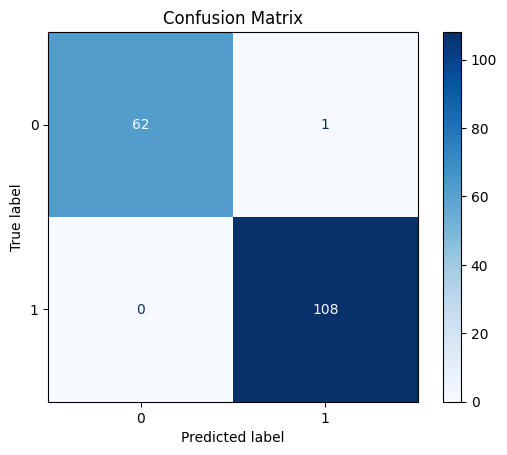

In [106]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

### Visualize Confusion Matrix

Definition: A Confusion Matrix is a table that compares the model's predicted labels with the actual labels, showing the numbers of True Positives, True Negatives, False Positives, and False Negatives.

Example: If the model correctly identifies 90 cancer patients and 95 healthy patients, while missing 5 cancer cases and incorrectly classifying 10 healthy patients as having cancer, these results are summarized in the confusion matrix.

## Methodology

This project follows a standard supervised machine learning workflow to build a binary classification model that predicts whether a tumor is malignant or benign using the Breast Cancer Wisconsin dataset.

### 1. Data Loading
- The dataset was loaded directly from `sklearn.datasets.load_breast_cancer(as_frame=True)` into a pandas DataFrame containing 30 numeric features and a binary `target` column.

### 2. Initial Data Inspection
- Displayed the first 5 rows using `df.head()` to preview feature names and sample values.
- Used `df.info()` to review column data types, non-null counts, and memory usage.
- Verified data types with `df.dtypes` to confirm all features were numeric.

### 3. Data Cleaning and Preprocessing
- **Missing Values Check:** `df.isnull().sum()` confirmed the dataset has **no missing values**, so no imputation was needed.
- **Duplicate Records Check:** `df.duplicated().sum()` confirmed **no duplicate rows**.
- **Data Type Validation:** All 30 feature columns are `float64`; the target column is `int64`. No incorrect types were found.
- **Invalid/String Values Check:** No object/string columns exist — all features are numeric and ML-ready.
- **Feature Scaling:** Since feature ranges vary widely (e.g., area vs. smoothness), `StandardScaler` was applied within the pipeline to standardize all features before model training.

### 4. Train-Test Split
- Split the data into features (`X`) and target (`y`).
- Used `train_test_split` with a 70/30 train-test ratio and `random_state=42` for reproducibility.

### 5. Model Pipeline Definition
- Built a `Pipeline` combining:
  1. `StandardScaler` — standardizes features (mean = 0, variance = 1).
  2. `LogisticRegression` (max_iter=1000) — the classification model.

### 6. Hyperparameter Tuning (GridSearchCV)
- Defined a hyperparameter grid covering:
  - `C`: regularization strength [0.01, 0.1, 1, 10, 100]
  - `solver`: ['lbfgs', 'liblinear']
  - `class_weight`: [None, 'balanced']
- Performed 5-fold cross-validation (`cv=5`) optimizing for `accuracy`, using `n_jobs=-1` for parallel computation.
- Best parameters found: `C=0.1`, `solver='liblinear'`, `class_weight=None`, achieving a cross-validation accuracy of ~97.7%.

### 7. Model Prediction
- Extracted the `best_estimator_` from the fitted `GridSearchCV` object.
- Generated predictions on the unseen test set (`X_test`).

### 8. Model Evaluation
Evaluated the model using standard classification metrics:
- **Accuracy:** 99.4% — overall proportion of correct predictions.
- **Precision:** 99.1% — proportion of predicted positives that were actually positive.
- **Recall:** 100% — proportion of actual positives correctly identified.
- **F1-Score:** 99.5% — harmonic mean of precision and recall.

### 9. Confusion Matrix Visualization
- Plotted a Confusion Matrix using `ConfusionMatrixDisplay.from_estimator()` to visualize True Positives, True Negatives, False Positives, and False Negatives, providing a clear breakdown of classification performance.